In [1]:
!pip install lifelines
import numpy as np
import pandas as pd
import os
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=c3e726081bb381fc387f227a24e5a641aa9dd554eedaccbcd6aaf2ad0b53fa4e
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = '/content/drive/MyDrive/DBA Folder/Capstone Project_Msc Project/Modelling/Data/Dataset1'

In [4]:
# Check if the path exists and list files to verify names
if os.path.exists(data_path):
    print("Files found in directory:", os.listdir(data_path))
else:
    print(f"Directory not found: {data_path}")

# ---------------------------
# Load data using corrected filenames
# ---------------------------
targets = pd.read_csv(os.path.join(data_path, 'fatima_targets.csv'))
merged = pd.read_csv(os.path.join(data_path, 'fatima_merged_dataset.csv'))

# Convert timestamp to datetime
merged['timestamp'] = pd.to_datetime(merged['timestamp'])

Files found in directory: ['fatima_operational_data.csv', 'fatima_sensor_data.csv', 'fatima_inspection_data.csv', 'fatima_targets.csv', 'fatima_engineered_features.csv', 'fatima_merged_dataset.csv']


In [5]:
# ---------------------------
# Compute per-segment aggregates from merged data
# ---------------------------
# We need: avg H2S, avg stress, exposure days
# Use equivalent_alternating_stress from engineered features as stress proxy
# (already in merged dataset)

# For each segment, compute mean of h2s_concentration and equivalent_alternating_stress
seg_agg = merged.groupby('segment_id').agg(
    avg_h2s=('h2s_concentration', 'mean'),
    avg_stress=('equivalent_alternating_stress', 'mean'),
    first_time=('timestamp', 'min'),
    last_time=('timestamp', 'max')
).reset_index()

# Compute exposure days
seg_agg['exposure_days'] = (seg_agg['last_time'] - seg_agg['first_time']).dt.total_seconds() / 86400

# Merge with targets
df = targets.merge(seg_agg, on='segment_id', how='left')

In [6]:
# ---------------------------
# Prepare survival data
# ---------------------------
# For segments that failed, duration = time_to_failure (cycles)
# For those that did not, duration = cycle_count (total observed cycles)
# Event = actual_failure (1 if failed, 0 otherwise)
# Ensure time_to_failure is not null for failed segments
df['duration'] = np.where(df['actual_failure'] == 1, df['time_to_failure'], df['cycle_count'])
df['event'] = df['actual_failure']

# Drop rows with missing duration or covariates
df = df.dropna(subset=['duration', 'event', 'avg_h2s', 'avg_stress', 'cycle_count', 'exposure_days'])

In [7]:
# ---------------------------
# Create interaction terms
# ---------------------------
df['H2S_x_cycles'] = df['avg_h2s'] * df['cycle_count']
df['H2S_x_days'] = df['avg_h2s'] * df['exposure_days']

In [8]:
# ---------------------------
# Standardize continuous covariates for better convergence (optional but recommended)
# ---------------------------
covariates = ['avg_h2s', 'avg_stress', 'cycle_count', 'exposure_days', 'H2S_x_cycles', 'H2S_x_days']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[covariates] = scaler.fit_transform(df[covariates])

In [9]:
# ---------------------------
# Fit Cox model with interactions
# ---------------------------
cph = CoxPHFitter(penalizer=0.01)  # small ridge penalty for stability
cph.fit(df_scaled, duration_col='duration', event_col='event', formula='avg_h2s + avg_stress + cycle_count + exposure_days + H2S_x_cycles + H2S_x_days')
cph.print_summary()

# Extract hazard ratios and confidence intervals
print("\nHazard Ratios and 95% CIs:")
hr_ci = cph.confidence_intervals_.copy()
hr_ci['hazard_ratio'] = cph.hazard_ratios_
# Using the correct column names for lifelines 0.30+
print(hr_ci[['hazard_ratio', '95% lower-bound', '95% upper-bound']])

<lifelines.CoxPHFitter: fitted with 4561 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 4561
number of events observed = 4561
   partial log-likelihood = -26376.34
         time fit was run = 2026-02-15 07:42:30 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
avg_h2s        0.26      1.29      0.10            0.06            0.45                1.07                1.56
avg_stress     6.22    501.64      0.07            6.07            6.36              434.53              579.12
cycle_count    0.01      1.01      0.03           -0.04            0.06                0.96                1.06
exposure_days -0.04      0.96      0.02           -0.07            0.00                0.93                1.00
H2S_x_cycles   0.34      1.41      0.06            0.23            0.45                1.26                1.58
H2S_x_days     0.21      1.23      0.10            0.01            0.41                1.01                1.50

               cmp to     z      p  -log2(p)
covariate                                   
avg_h2s          0.00  2.63   0.01      6.85
avg_stress       0.00 84.86 <0.005       inf
cycle_count      0.00  0.42   0.68      0.57
exposure_days    0.00 -1.95   0.05      4.29
H2S_x_cycles     0.00  5.89 <0.005     27.99
H2S_x_days       0.00  2.06   0.04      4.67
---
Concordance = 0.95
Partial AIC = 52764.68
log-likelihood ratio test = 14991.15 on 6 df
-log2(p) of ll-ratio test = inf


Hazard Ratios and 95% CIs:
               hazard_ratio  95% lower-bound  95% upper-bound
covariate                                                    
avg_h2s            1.291839         0.064902         0.447231
avg_stress       501.644941         6.074274         6.361512
cycle_count        1.010872        -0.039825         0.061452
exposure_days      0.964124        -0.073247         0.000175
H2S_x_cycles       1.406566         0.227726         0.454578
H2S_x_days         1.232451         0.010235         0.407775


In [11]:
from scipy.stats import chi2

# ---------------------------
# Likelihood Ratio Test for interactions
# ---------------------------
# Fit reduced model without interactions
cph_reduced = CoxPHFitter(penalizer=0.01)
cph_reduced.fit(df_scaled, duration_col='duration', event_col='event', formula='avg_h2s + avg_stress + cycle_count + exposure_days')

# Compute LRT
ll_full = cph.log_likelihood_
ll_reduced = cph_reduced.log_likelihood_
lrt_stat = -2 * (ll_reduced - ll_full)
df_diff = len(cph.params_) - len(cph_reduced.params_)
p_value_lrt = 1 - chi2.cdf(lrt_stat, df_diff)

print(f"\nLikelihood Ratio Test for interactions (df = {df_diff}):")
print(f"LR statistic = {lrt_stat:.4f}, p = {p_value_lrt:.8f}")

# ---------------------------
# Wald test for individual interaction coefficients
# ---------------------------
# Already in summary, but we can extract
wald_p = cph.summary.loc[['H2S_x_cycles', 'H2S_x_days'], 'p']
print("\nWald test p-values for interactions:")
print(wald_p)


Likelihood Ratio Test for interactions (df = 2):
LR statistic = 52.0394, p = 0.00000000

Wald test p-values for interactions:
covariate
H2S_x_cycles    3.747171e-09
H2S_x_days      3.931426e-02
Name: p, dtype: float64


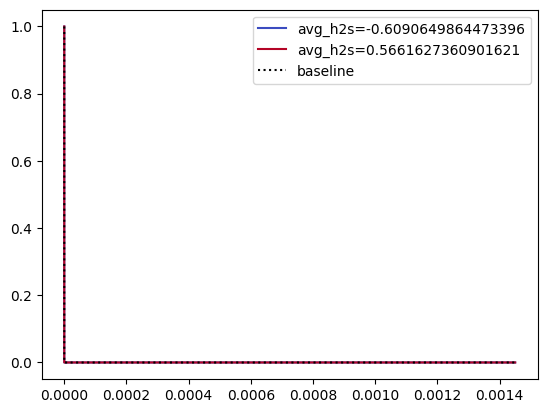

In [12]:
# ---------------------------
# (Optional) Plot baseline survival
# ---------------------------
cph.plot_covariate_groups('avg_h2s', values=[df_scaled['avg_h2s'].quantile(0.25), df_scaled['avg_h2s'].quantile(0.75)], cmap='coolwarm')
plt.show()

## RQ3: Corrosion–Fatigue Synergy (Cox Proportional Hazards)

**Research Question (RQ3):** How do environmental factors (H₂S concentration, exposure time) interact with mechanical cycling to accelerate fatigue damage, and can this synergy be modeled dynamically?

**Model:** Cox Proportional Hazards (CoxPH)

### Hypotheses
- **H₀:** The synergy interaction term between mechanical cycling and H₂S concentration is **zero** (β = 0). Corrosion and fatigue act additively.
- **H₁:** The synergy interaction term is **positive and significant** (β > 0), indicating synergistic acceleration of failure hazard.

### Statistical Tests (as implemented below)
- **Wald test** on the interaction coefficient (`H2S_x_cycles`) from the fitted CoxPH model.
- **Likelihood Ratio Test (LRT)** comparing the full model (with interactions) vs reduced model (no interactions).
- **Hazard ratio (HR) with 95% CI** for the synergy term.


,synergy_term,beta_hat,SE(beta),Wald_z,Wald_p,LRT_stat,LRT_df,LRT_p,HR=exp(beta),HR_CI_low,HR_CI_high,alpha,decision
0,H2S_x_cycles,0.341152,0.057872,5.894984,3.747171e-09,52.03944,2,5.009326e-12,1.406566,1.255741,1.575508,0.05,Reject H₀ (supports H₁: positive synergy)



Definitive RQ3 hypothesis conclusion:
Reject H₀ (supports H₁: positive synergy)


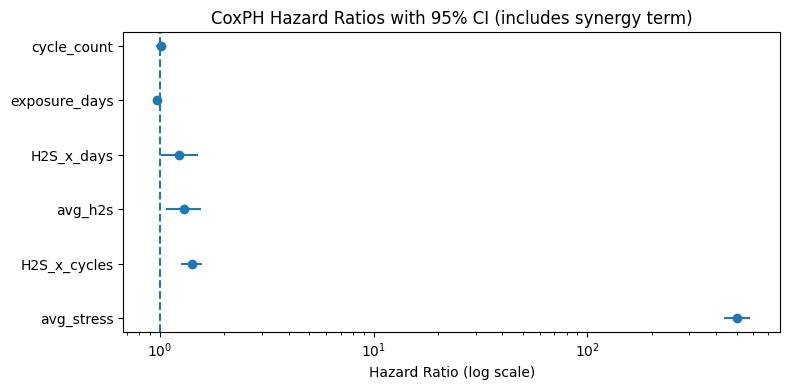

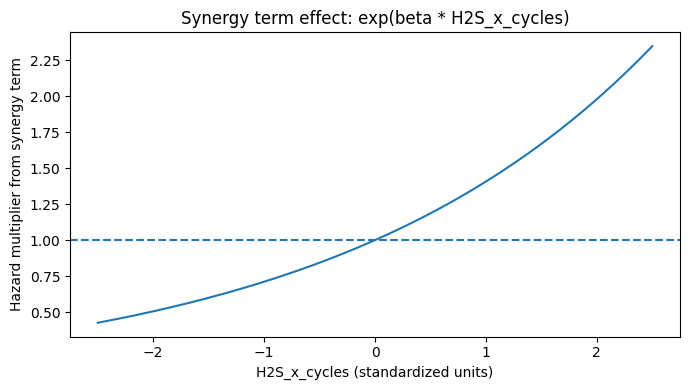

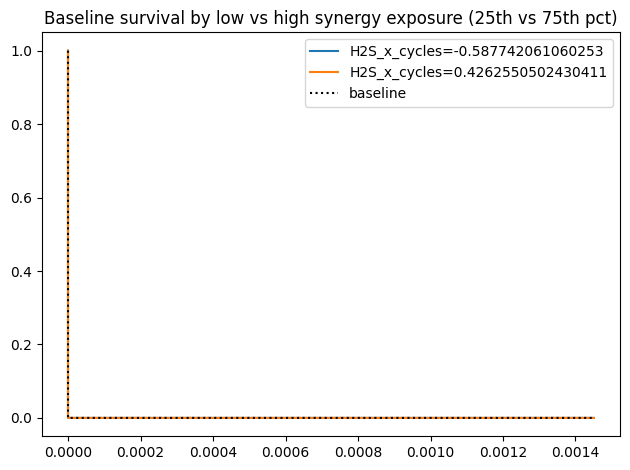

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ---------------------------
# RQ3: Synergy term inference + summary tables
# ---------------------------

# Safety checks
if 'cph' not in globals():
    raise RuntimeError("Expected a fitted CoxPHFitter named `cph`. Run the model-fit cell first.")

if 'cph_reduced' not in globals():
    raise RuntimeError("Expected a fitted reduced CoxPHFitter named `cph_reduced`. Run the LRT cell first.")

synergy_term = 'H2S_x_cycles'
if synergy_term not in cph.params_.index:
    raise KeyError(f"Synergy term '{synergy_term}' not found in fitted covariates. "
                   f"Available: {list(cph.params_.index)}")

# Wald test (from lifelines summary)
summ = cph.summary.copy()
beta = float(summ.loc[synergy_term, 'coef'])
se = float(summ.loc[synergy_term, 'se(coef)'])
wald_z = float(summ.loc[synergy_term, 'z'])
wald_p = float(summ.loc[synergy_term, 'p'])

# LRT (already computed above, but recompute robustly)
ll_full = float(cph.log_likelihood_)
ll_reduced = float(cph_reduced.log_likelihood_)
lrt_stat = -2.0 * (ll_reduced - ll_full)
df_diff = int(len(cph.params_) - len(cph_reduced.params_))
lrt_p = float(chi2.sf(lrt_stat, df_diff))

# Hazard ratio and CI for synergy term
hr = float(np.exp(beta))
ci_low = float(np.exp(summ.loc[synergy_term, 'coef lower 95%']))
ci_high = float(np.exp(summ.loc[synergy_term, 'coef upper 95%']))

# Decision rule for RQ3 (as stated): β > 0 and statistically significant
alpha = 0.05
reject_h0 = (beta > 0) and (wald_p < alpha) and (lrt_p < alpha)

decision = "Reject H₀ (supports H₁: positive synergy)" if reject_h0 else "Fail to reject H₀ (insufficient evidence of positive synergy)"

rq3_results_df = pd.DataFrame([{
    "synergy_term": synergy_term,
    "beta_hat": beta,
    "SE(beta)": se,
    "Wald_z": wald_z,
    "Wald_p": wald_p,
    "LRT_stat": lrt_stat,
    "LRT_df": df_diff,
    "LRT_p": lrt_p,
    "HR=exp(beta)": hr,
    "HR_CI_low": ci_low,
    "HR_CI_high": ci_high,
    "alpha": alpha,
    "decision": decision
}])

display(rq3_results_df)

print("\nDefinitive RQ3 hypothesis conclusion:")
print(decision)

# ---------------------------
# Visualization 1: Forest plot of hazard ratios (top covariates)
# ---------------------------
hr_table = cph.summary.copy()
hr_table['HR'] = np.exp(hr_table['coef'])
hr_table['HR_low'] = np.exp(hr_table['coef lower 95%'])
hr_table['HR_high'] = np.exp(hr_table['coef upper 95%'])
hr_table = hr_table.sort_values('HR')

# Plot up to top 10 by |coef| for readability, but always include synergy term
top = hr_table.reindex(hr_table['coef'].abs().sort_values(ascending=False).index)
top = top.head(10)
if synergy_term not in top.index:
    top = pd.concat([top, hr_table.loc[[synergy_term]]], axis=0)

labels = top.index.tolist()
ypos = np.arange(len(labels))

plt.figure(figsize=(8, max(4, 0.4*len(labels))))
plt.hlines(y=ypos, xmin=top['HR_low'], xmax=top['HR_high'])
plt.plot(top['HR'], ypos, marker='o', linestyle='None')
plt.axvline(1.0, linestyle='--')
plt.yticks(ypos, labels)
plt.xscale('log')
plt.xlabel('Hazard Ratio (log scale)')
plt.title('CoxPH Hazard Ratios with 95% CI (includes synergy term)')
plt.tight_layout()
plt.show()

# ---------------------------
# Visualization 2: Synergy effect curve (interaction term → hazard multiplier)
# Note: covariates were standardized, so 'H2S_x_cycles' is in SD units.
# ---------------------------
beta_int = beta
x_vals = np.linspace(-2.5, 2.5, 200)   # interaction term in standardized units
haz_mult = np.exp(beta_int * x_vals)

plt.figure(figsize=(7,4))
plt.plot(x_vals, haz_mult)
plt.axhline(1.0, linestyle='--')
plt.xlabel('H2S_x_cycles (standardized units)')
plt.ylabel('Hazard multiplier from synergy term')
plt.title('Synergy term effect: exp(beta * H2S_x_cycles)')
plt.tight_layout()
plt.show()

# ---------------------------
# Visualization 3: Survival curves by low vs high synergy exposure
# ---------------------------
if 'df_scaled' in globals() and synergy_term in df_scaled.columns:
    q25 = df_scaled[synergy_term].quantile(0.25)
    q75 = df_scaled[synergy_term].quantile(0.75)
    cph.plot_covariate_groups(synergy_term, values=[q25, q75])
    plt.title('Baseline survival by low vs high synergy exposure (25th vs 75th pct)')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping survival-curve plot: df_scaled or synergy term column not available.")
